C:\Users\Marcos\AppData\Local\Temp\ipykernel_16656\1001300270.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="mako")


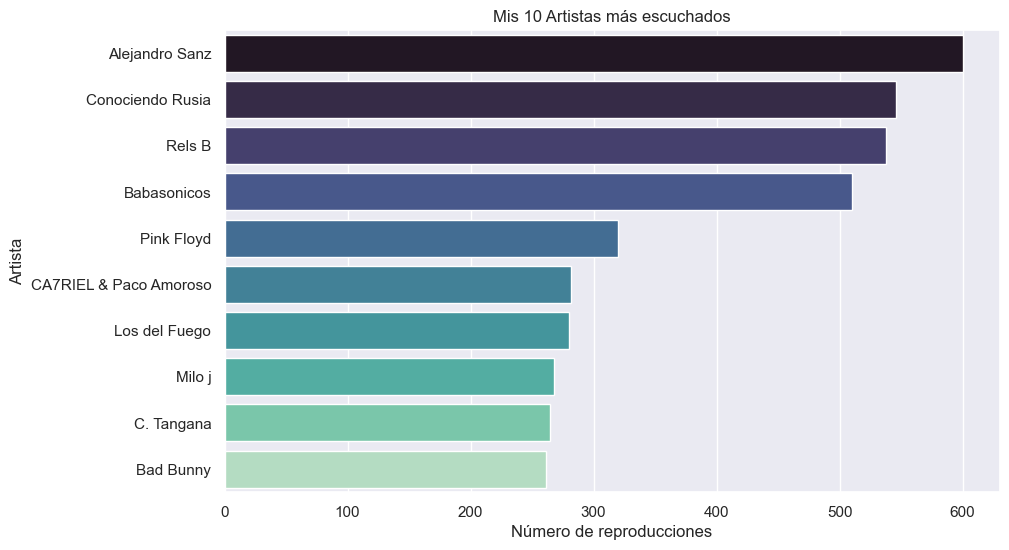

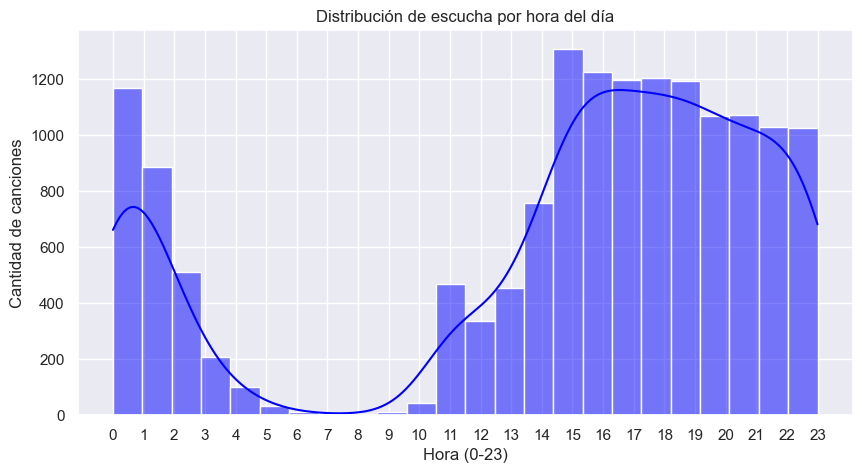

C:\Users\Marcos\AppData\Local\Temp\ipykernel_16656\1001300270.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mes', order=orden_meses, palette="crest")


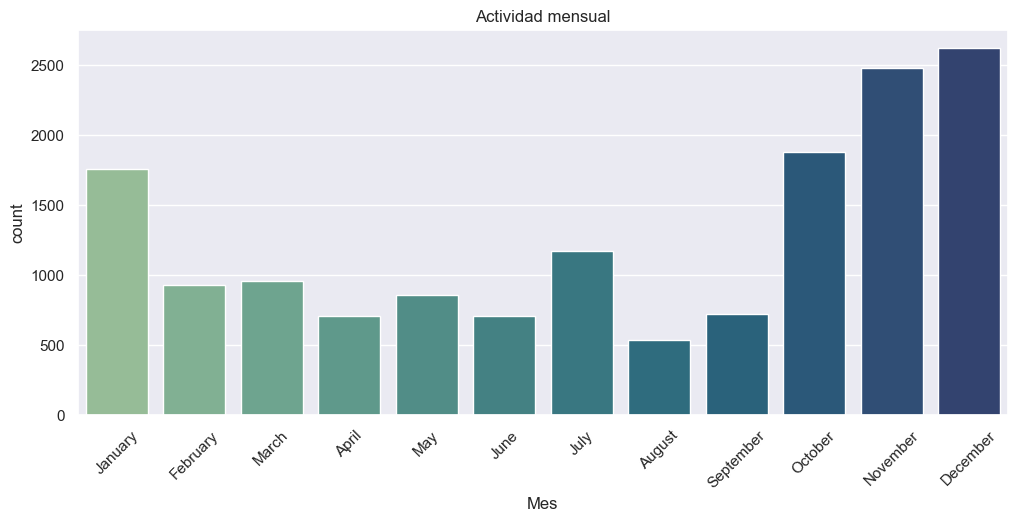

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

try:
    # Cargar datos desde el archivo JSON
    url = "data/Streaming_History_Audio_2022-2026_0.json" 
    df = pd.read_json(url)

    # Creamos nuestro Dataframe con los datos que nos interesa del Json
    # Renombramos las columnas para mayor legibilidad
    df = df[["master_metadata_track_name", "master_metadata_album_artist_name","master_metadata_album_album_name", "ts"]].rename(
        columns={
            "master_metadata_track_name": "Canción",
            "master_metadata_album_artist_name": "Artista",
            "master_metadata_album_album_name": "Albúm",
            "ts": "Fecha"
        }
    )

    # Eliminamos las canciones que no tengan nombre
    df = df.dropna(subset=["Canción"])
    
    # Convertimos la fecha de formato pandas a datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # Extraemos datos de fechas para metricas futuras
    df["Año"] = df["Fecha"].dt.year
    df["Mes"] = df["Fecha"].dt.month_name()
    df['dia_semana'] = df['Fecha'].dt.day_name()
    df["Hora"] = df["Fecha"].dt.hour

    # Mostramos las primeras cinco
    # print(df.head())
    
    # Graficamos top 10 artistas
    plt.figure(figsize=(10, 6)) # Tamaño del lienzo
    top_artistas = df['Artista'].value_counts().head(10)

    sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="mako")

    plt.title("Mis 10 Artistas más escuchados")
    plt.xlabel("Número de reproducciones")
    plt.show()

    # Mapa de escucha horaria
    plt.figure(figsize=(10, 5))
    sns.histplot(df['Hora'], bins=24, kde=True, color="blue")

    plt.title("Distribución de escucha por hora del día")
    plt.xticks(range(0, 24))
    plt.xlabel("Hora (0-23)")
    plt.ylabel("Cantidad de canciones")
    plt.show()

    # Mapa de consumo anual
    plt.figure(figsize=(12, 5))
    # Ordenamos los meses cronológicamente para que la línea tenga sentido
    orden_meses = ["January", "February", "March", "April", "May", "June", 
                    "July", "August", "September", "October", "November", "December"]

    sns.countplot(data=df, x='Mes', order=orden_meses, palette="crest")
    plt.xticks(rotation=45)
    plt.title("Actividad mensual")
    plt.show()


except Exception as e:
    print(f"Ocurrió un error: {e}")
